In [79]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma, factorial
from scipy.integrate import solve_ivp

TWO_PARTICLE_POTENTIAL_DEPTH = -0.1 # MeV
SCATTERING_STRENGTH = -24.22 # MeV
SCATTERING_RANGE = 2 # fm
NN_REDUCED_MASS = 939.6 / 2 #MeV
HBAR_C = 197.3 #MeV fm
R_MAX = 400

In [82]:
def V_nn(r, S, b): #form of the interaction potential
    return 2 * (NN_REDUCED_MASS / HBAR_C**2) * S * np.exp(-(r/b)**2)

def ode_solution(r_vals, S, b, r_max = R_MAX):
    derivative_inital_value = 1
    reduced_func_inital_value = 0
    inital_values = [derivative_inital_value, reduced_func_inital_value]

    def func(t, y):
        return [V_nn(t, S, b) * y[1], y[0]]
    t_span = [0, R_MAX]
    sol1 = solve_ivp(func, t_span, inital_values, t_eval=r_vals)
    return sol1

def asymptotic_fit(r_vals, u_r_vals):
    def func(r, A, a_s):
        return A * (1 - r / a_s)
    asym_fit_params, asym_fit_covarience = scipy.optimize.curve_fit(func, r_vals, u_r_vals, p0=[1, -15])
    return asym_fit_params, asym_fit_covarience


In [88]:
r_vals = np.linspace(0, R_MAX, 30001)
sol1 = ode_solution(r_vals, SCATTERING_STRENGTH, SCATTERING_RANGE)

print(r_vals[1000:])
asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])
print(asymptotic_fit_parameters)
print(asymptotic_fit_covarience)

[ 13.33333333  13.34666667  13.36       ... 399.97333333 399.98666667
 400.        ]
[  1.44564509 -15.2540619 ]
[[ 4.26578913e-28 -4.75834433e-27]
 [-4.75834433e-27  5.31229701e-26]]


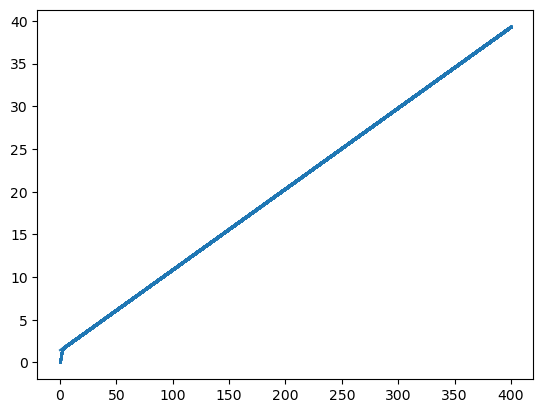

In [89]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(r_vals, sol1.y[1], s=1)
ax.plot(r_vals, asymptotic_fit_parameters[0] * (1 - (r_vals) / asymptotic_fit_parameters[1]))